In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import plotting,utils, processing
allmeshes = utils.load_mesh()

import squidpy as sq
import scanpy as sc

import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")


/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
adata_foo = sc.read_h5ad("/home/shuonan.chen/scratch_shuonan//LC_scRNAseq/conversion_files/snRNAseq_LCNE_BN_new.h5ad")
adata_sc = anndata.AnnData(adata_foo.layers['BN'])
adata_sc.obs = adata_foo.obs.copy()
adata_sc.obsm = adata_foo.obsm.copy()
adata_sc.var = adata_foo.var.copy()

filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)
var_names = adata_mer.var_names.intersection(adata_sc.var_names)
adata_mer = adata_mer[:,var_names]  # 314 genes 


adata_mer = adata_mer[adata_mer.obs['leiden']!='5',:]
adata_mer.shape
sc.pp.normalize_total(adata_mer, 1e4)

/scratch/fast/1339261/ipykernel_3721481/4029516027.py:15: FutureWarning: The specified parameters ('target_sum',) are no longer positional. Please specify them like `target_sum=10000.0`
  sc.pp.normalize_total(adata_mer, 1e4)
/allen/aind/scratch/shuonan.chen/conda_envs/torch_on_gpu_py310/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [3]:
coords  = adata_mer.obsm['spatial'].copy()
coords = processing.get_hemi(coords)

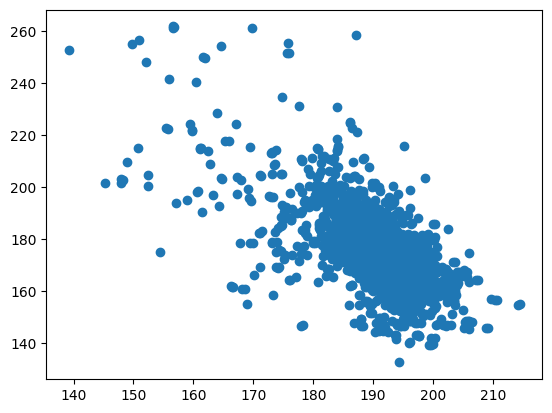

In [4]:
plt.scatter(coords[:,2],coords[:,1]) # just to make sure only one side is left 

In [5]:
from scipy import sparse

In [6]:
if sparse.issparse(adata_mer.X):
    X = adata_mer.X.toarray()   # shape (N, G)
else:
    X = np.asarray(adata_mer.X)  # already dense
N, G = X.shape

In [39]:
coords_mean = coords.mean(axis=0)          # shape (3,)
coords_centered = coords - coords_mean     # shape (N, 3)
coords_std = coords_centered.std(axis=0)    # shape (3,)
# coords_scaled = coords_centered / coords_std  # shape (N,3)
coords_scaled = coords_centered / 1

In [40]:
coords_std.shape

(3,)

In [41]:
coords_mean.shape

(3,)

In [42]:
# ─── 3. Center each gene’s expression ───────────────────────────────────────────
gene_means = X.mean(axis=0)       # shape (G,)
Y_centered = X - gene_means       # shape (N, G)
Y_std = Y_centered.std(axis=0)    # shape (3,)
Y_scaled = Y_centered / Y_std  # shape (N,3)

In [43]:
# ─── 4. Compute covariance vectors for each gene ──────────────────────────
covs = coords_scaled.T.dot(Y_scaled)    

In [44]:
# Pre‐allocate arrays for u (3×G) and the correlation scalars (G,)
us = np.zeros((3, G), dtype=np.float64)
corrs = np.zeros(G, dtype=np.float64)


In [45]:
eps = 1e-12
for g in range(G):
    w = covs[:, g]   # shape (3,)
    norm_w = np.linalg.norm(w)
    if norm_w < 1e-12:
        # If w≈0, expression for gene g has (almost) zero linear covariance with any direction.
        # We’ll set u^(g) to NaN or a zero‐vector and correlation to 0.
        us[:, g] = np.nan
        corrs[g] = 0.0
        continue
    u = w / norm_w           # shape (3,)
    us[:, g] = u
    x_proj = coords_scaled.dot(u)     # shape (N,)
    y_g = Y_scaled[:, g]              # shape (N,)
    if np.var(y_g) < eps or np.var(x_proj) < eps:
        corrs[g] = 0.0
    else:
        corrs[g] = np.corrcoef(y_g, x_proj)[0, 1]

In [46]:
interested_vectors = []
top10_idx = np.argsort(np.abs(corrs))[::-1][:10]
for idx in top10_idx:
    gene_name = adata_mer.var_names[idx]
#     print(f"{gene_name:20s}  corr = {corrs[idx]: .3f}  axis = {us[:, idx]}")
    print(f"{gene_name:10s}  corr = {corrs[idx]: .3f}  axis = {us[:, idx]}")

Tacr3       corr =  0.557  axis = [-0.27861065  0.88270929 -0.37841831]
Tmem178     corr =  0.539  axis = [-0.3180371   0.87635527 -0.36173725]
Galr1       corr =  0.504  axis = [-0.35559416  0.84313948 -0.40332197]
Oprm1       corr =  0.498  axis = [ 0.28015164 -0.87531017  0.39414105]
Ecel1       corr =  0.495  axis = [-0.37800478  0.83214825 -0.40576061]
Nefm        corr =  0.451  axis = [-0.41435517  0.81720756 -0.40060154]
Nefh        corr =  0.438  axis = [-0.39614434  0.82674231 -0.39945816]
Pde11a      corr =  0.425  axis = [ 0.29704778 -0.87715612  0.37730593]
Chodl       corr =  0.420  axis = [ 0.39816315 -0.82854019  0.39368421]
Pdyn        corr =  0.419  axis = [ 0.16574836 -0.91267932  0.37355581]


In [47]:
top10_idx = np.argsort(np.abs(corrs))[-10:][::-1]
us_top = us[:, top10_idx]


In [48]:
v_init = np.nanmean(us_top, axis=1)
v_init = us_top[:,0].copy()

In [49]:
# 4. Align each vector to v_init (flip sign if obtuse)
us_aligned = us_top.copy()
for i in range(us_aligned.shape[1]):
    if np.dot(us_aligned[:, i], v_init) < 0:
        us_aligned[:, i] *= -1
v_avg = np.nanmean(us_aligned, axis=1)
norm_v_avg = np.linalg.norm(v_avg)
v_avg_unit = v_avg / norm_v_avg

In [50]:
dots = np.dot(us_aligned.T, v_avg_unit)
dots = np.clip(dots, -1.0, 1.0)
angles_deg = np.degrees(np.arccos(dots))


In [51]:
angles_deg

array([3.24984454, 1.98156489, 1.94595795, 2.95659528, 3.34032551,
       5.49259995, 4.31441195, 2.21520243, 4.34578612, 9.8999083 ])

In [52]:
# 6. Summary metrics
mean_angle = np.nanmean(angles_deg)
median_angle = np.nanmedian(angles_deg)


In [53]:
mean_angle   = np.nanmean(angles_deg)
median_angle = np.nanmedian(angles_deg)

print("Top 10 genes:", list(adata_mer.var_names[top10_idx]))
print("Consensus unit vector:", v_avg_unit)
print(f"Mean angle to consensus (°): {mean_angle:.2f}")
print(f"Median angle to consensus (°): {median_angle:.2f}")
print("Individual angles (°):", np.round(angles_deg, 2))

Top 10 genes: ['Tacr3', 'Tmem178', 'Galr1', 'Oprm1', 'Ecel1', 'Nefm', 'Nefh', 'Pde11a', 'Chodl', 'Pdyn']
Consensus unit vector: [-0.32923105  0.85992915 -0.39003689]
Mean angle to consensus (°): 3.97
Median angle to consensus (°): 3.30
Individual angles (°): [3.25 1.98 1.95 2.96 3.34 5.49 4.31 2.22 4.35 9.9 ]


In [54]:
coords_mean,coords_std

(array([419.29172862, 175.96398752, 189.72246934]),
 array([ 7.02636427, 15.12289336,  7.82848712]))

In [55]:
v_orig = v_avg_unit * coords_std # + coords_mean # shape (3,)

# 2) Renormalize to length 1:
v_orig_unit = v_orig / np.linalg.norm(v_orig)

print("Consensus direction in original coords:", v_orig_unit)

Consensus direction in original coords: [-0.17063378  0.95924851 -0.22522526]


In [56]:
np.linalg.norm(v_orig_unit)

np.float64(1.0)

# the vector in the original space, for the top 10 genes. 

In [57]:
foo = us_top.T * coords_std
foonorm = np.array([np.linalg.norm(foo[m]) for m in range(10)])

foo =foo/foonorm[:,None]
foo

array([[-0.14171991,  0.96639592, -0.21446305],
       [-0.1626947 ,  0.96489497, -0.20617501],
       [-0.18685758,  0.95358578, -0.23613218],
       [ 0.1433279 , -0.96383739,  0.22466551],
       [-0.20048058,  0.94990453, -0.23976848],
       [-0.2226118 ,  0.94495695, -0.23979229],
       [-0.21110712,  0.94825211, -0.23717445],
       [ 0.15180103, -0.96478274,  0.21482717],
       [ 0.21189116, -0.94900738,  0.23342478],
       [ 0.08226531, -0.97496702,  0.20657138]])

In [58]:
coords.shape

(2252, 3)

In [59]:
covs.shape

(3, 314)

In [60]:
Y_scaled.shape

(2252, 314)

In [61]:
us.shape

(3, 314)

In [62]:
projected_for_each_gene = (coords_scaled@us) # (N x 314). 314 is the num of vectors

Text(0.5, 1.0, 'Tacr3r=0.557')

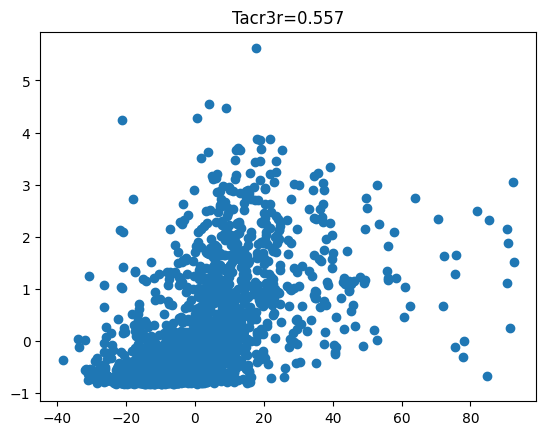

In [63]:
j = top10_idx[0]
plt.scatter(projected_for_each_gene[:,j], Y_scaled[:,j])
r = np.corrcoef(projected_for_each_gene[:,j], Y_scaled[:,j])[0,1]
plt.title(list(adata_mer.var_names)[j]+f'r={np.around(r,3)}')

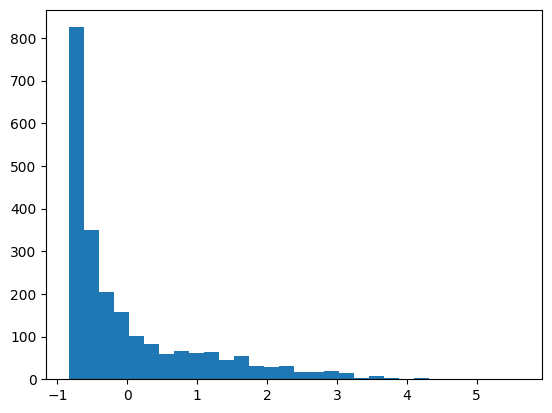

In [64]:
plt.hist(Y_scaled[:,j], bins = 30);

In [65]:
Y_scaled.min()

np.float32(-4.071311)

In [66]:
Y_scaled.max()

np.float32(41.87705)

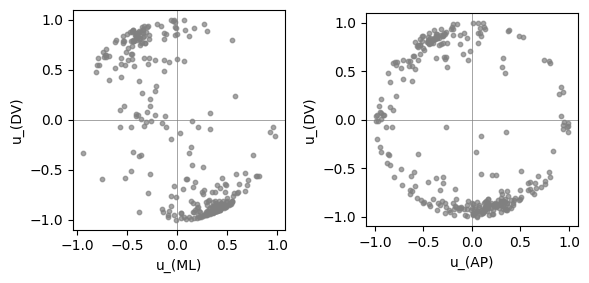

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(6,3))

axes[0].scatter(us[2, :], us[1,:], s=10, alpha=0.7, color = 'gray')
axes[0].set_xlabel('u_(ML)')
axes[0].set_ylabel('u_(DV)')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_aspect('equal')
axes[1].scatter(us[0, :], us[1, :], s=10, alpha=0.7, color = 'gray')
axes[1].set_xlabel('u_(AP)')
axes[1].set_ylabel('u_(DV)')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

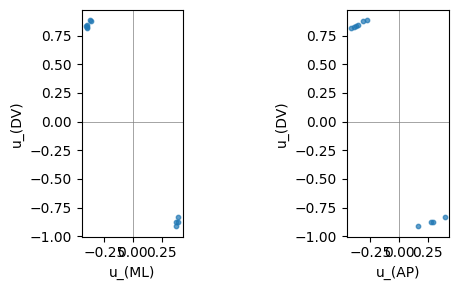

In [68]:
top10_idx = np.argsort(np.abs(corrs))[-10:][::-1]
fig, axes = plt.subplots(1, 2, figsize=(6,3))

axes[0].scatter(us[2, top10_idx], us[1,top10_idx], s=10, alpha=0.7)
axes[0].set_xlabel('u_(ML)')
axes[0].set_ylabel('u_(DV)')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_aspect('equal')
axes[1].scatter(us[0, top10_idx], us[1, top10_idx], s=10, alpha=0.7)
axes[1].set_xlabel('u_(AP)')
axes[1].set_ylabel('u_(DV)')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_vectors_in_multiple_views(us_aligned, v_avg_unit, view_angles):
    """
    Plot top-10 aligned unit vectors and consensus direction
    in 3 subplots with different elevation/azimuth angles.

    Parameters
    ----------
    us_aligned : np.ndarray of shape (3, 10)
        Aligned unit vectors for top 10 genes.
    v_avg_unit : np.ndarray of shape (3,)
        Consensus unit vector.
    view_angles : list of tuples
        Each tuple is (elev, azim) for a subplot.
    """
    fig = plt.figure(figsize=(15, 5))
    
    for i, (elev, azim) in enumerate(view_angles):
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        # Plot individual gene vectors
        for v in us_aligned.T:
            ax.quiver(0, 0, 0, v[0], v[1], v[2], length=1, normalize=True, linewidth=1, color='gray')
        # Plot consensus vector
        ax.quiver(0, 0, 0, v_avg_unit[0], v_avg_unit[1], v_avg_unit[2],
                  length=1, normalize=True, linewidth=3, color='red')
        # Set view angle
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"elev={elev}, azim={azim}")
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()    

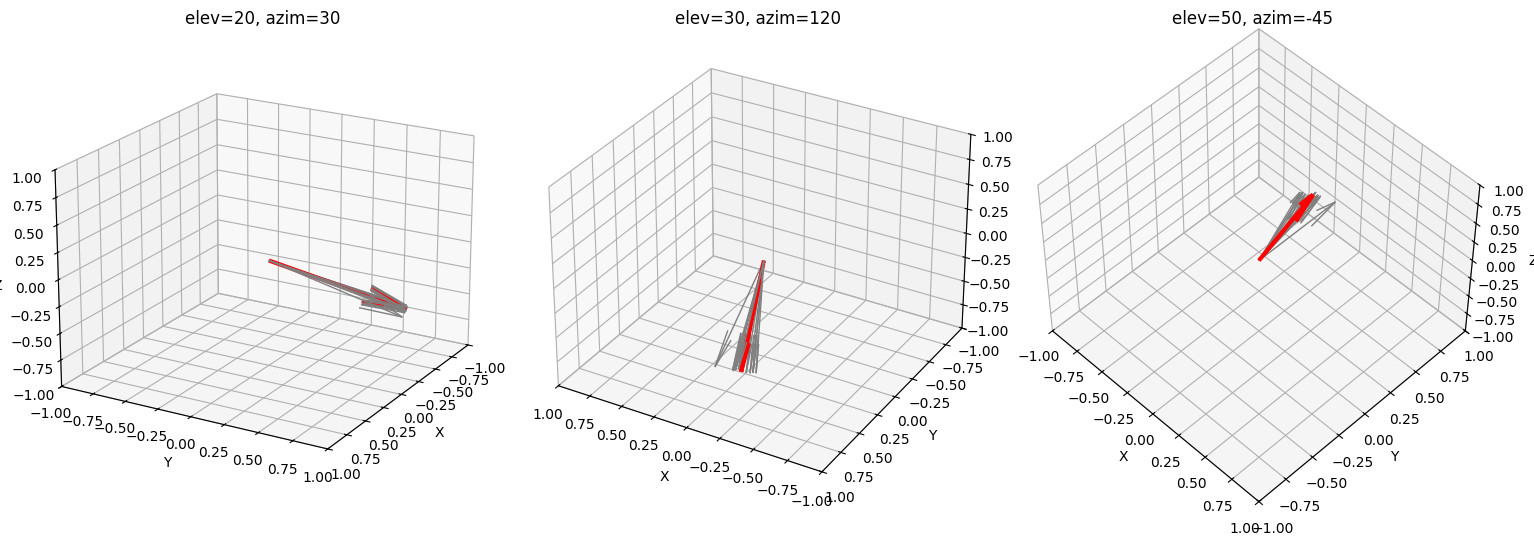

In [79]:
views = [(20, 30), (30, 120), (50, -45)]
# Call the function (requires `us_aligned` and `v_avg_unit` available)
plot_vectors_in_multiple_views(us_aligned, v_avg_unit, views)

In [98]:
mesh.faces

TrackedArray([[    0,     2,     1],
              [    0,     3,     2],
              [    0,     4,     3],
              ...,
              [19120, 19144, 19145],
              [19120, 19147, 19144],
              [19120, 19123, 19147]])

In [96]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_vectors_with_mesh( us_aligned, v_avg_unit, view_angles):
    """
    Visualize top-10 aligned unit vectors, consensus direction, and a 3D mesh in multiple views.

    Parameters
    ----------
    mesh_path : str
        Path to your mesh file (e.g., .obj, .ply, .stl).
    us_aligned : np.ndarray of shape (3, 10)
        Aligned unit vectors for top 10 genes.
    v_avg_unit : np.ndarray of shape (3,)
        Consensus unit vector.
    view_angles : list of (elev, azim)
        List of elevation/azimuth pairs for subplots.
    """
    allmeshes = utils.load_mesh()
    mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
#     mesh.vertices /=25
    verts = np.asarray(mesh.vertices/25)
    faces = np.asarray(mesh.faces)
    face_verts = verts[faces]/25

    fig = plt.figure(figsize=(15, 5))
    for i, (elev, azim) in enumerate(view_angles):
        ax = fig.add_subplot(1, 3, i+1, projection='3d')
        
        # Plot mesh
        poly = Poly3DCollection(face_verts, facecolors='lightgray', edgecolors='gray', alpha=0.5)
#         ax.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha = .1, label = '67%')
        ax.add_collection3d(poly)
        
        # Plot each top-10 gene vector
        for v in us_aligned.T:
            ax.quiver(0, 0, 0, v[0], v[1], v[2],
                      length=1, normalize=True, linewidth=1, color='blue', alpha=0.7)
        
        # Plot consensus vector
        ax.quiver(0, 0, 0, v_avg_unit[0], v_avg_unit[1], v_avg_unit[2],
                  length=1, normalize=True, linewidth=3, color='red')
        
        # Set view
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(f"View elev={elev}°, azim={azim}°")
        ax.set_xlim([-1, 1])
        ax.set_ylim([-1, 1])
        ax.set_zlim([-1, 1])
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()


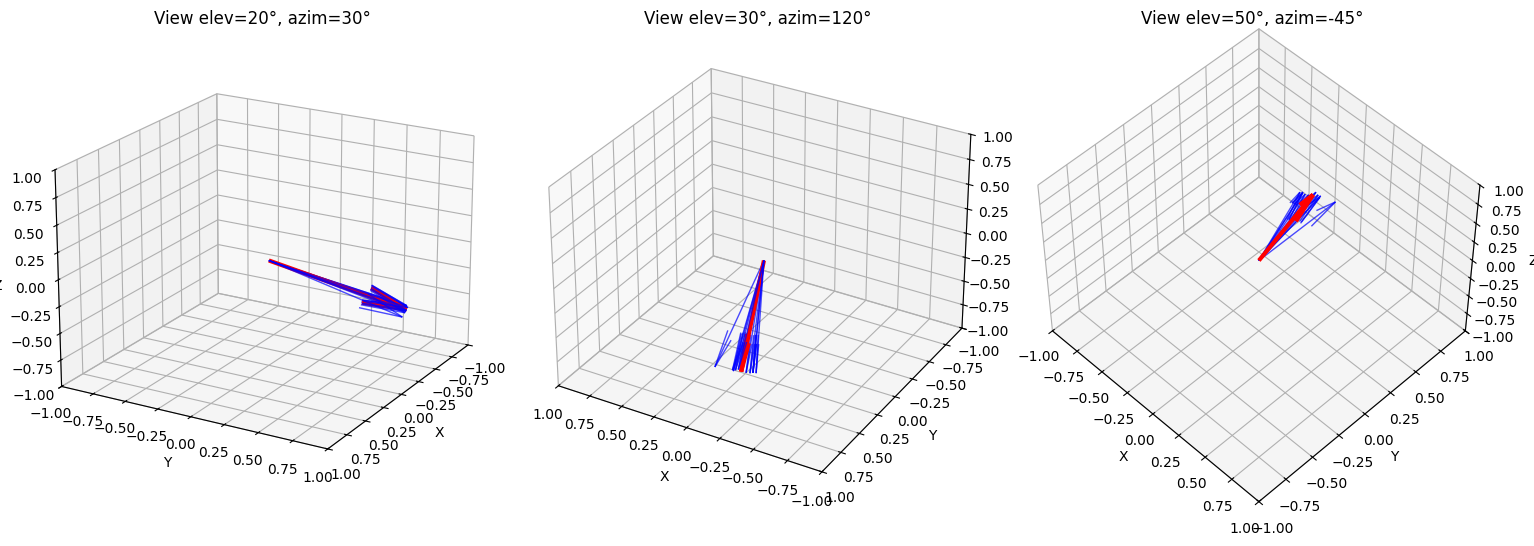

In [97]:

plot_vectors_with_mesh(us_aligned, v_avg_unit, views)



